In [ ]:
prediction_files = {
    'RegNetY-16GF': 'path/to/experiments/experiment-0023/predictions.csv',
    'ConvNeXt-B': 'path/to/experiments/experiment-0015/predictions.csv',
    'DeiT-B': 'path/to/experiments/experiment-0013/predictions.csv',
    'SwinV2-B': 'path/to/experiments/experiment-0017/predictions.csv',
    'Vim-B': 'path/to/experiments/experiment-0011/predictions.csv',
    'MambaVision-B': 'path/to/experiments/experiment-0008/predictions.csv',
}


In [7]:
import numpy as np
import pandas as pd
from itertools import combinations
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests


def perform_significance_tests(predictions_dict, labels, alpha=0.05, verbose=True):
    """
    Pairwise McNemar exact tests with Holm–Bonferroni correction and effect size.

    Parameters
    ----------
    predictions_dict : dict
        {model_name : numpy array of predictions (n_samples,)}
    labels : numpy array
        True labels (n_samples,)
    alpha : float
        Significance level
    verbose : bool
        Whether to print results

    Returns
    -------
    results_df : pandas DataFrame
    """

    labels = np.asarray(labels)
    n_samples = len(labels)

    # sanity check
    for name, pred in predictions_dict.items():
        if len(pred) != n_samples:
            raise ValueError(f"{name} predictions length != labels length")

    if verbose:
        print("=" * 80)
        print("PAIRWISE MCNEMAR EXACT TEST (HOLM–BONFERRONI CORRECTED)")
        print("=" * 80)

    results = []
    raw_p_values = []
    comparisons = []

    model_names = list(predictions_dict.keys())

    # ---------- pairwise comparisons ----------
    for model1, model2 in combinations(model_names, 2):

        pred1 = np.asarray(predictions_dict[model1])
        pred2 = np.asarray(predictions_dict[model2])

        correct1 = (pred1 == labels)
        correct2 = (pred2 == labels)

        # full contingency table components
        n11 = np.sum(correct1 & correct2)     # both correct
        n00 = np.sum(~correct1 & ~correct2)   # both wrong
        n01 = np.sum(~correct1 & correct2)    # M1 wrong, M2 correct
        n10 = np.sum(correct1 & ~correct2)    # M1 correct, M2 wrong

        table = [[n11, n10],
                 [n01, n00]]

        # ---- Degenerate case (identical predictions) ----
        if (n01 + n10) == 0:
            p_value = 1.0
        else:
            result = mcnemar(table, exact=True)
            p_value = float(result.pvalue)

        # ---- Effect size (discordance difference) ----
        effect_size = (n10 - n01) / n_samples

        # who is better?
        if effect_size > 0:
            better_model = model1
        elif effect_size < 0:
            better_model = model2
        else:
            better_model = "Tie"

        raw_p_values.append(p_value)
        comparisons.append((model1, model2, n11, n00, n01, n10, effect_size, better_model))

    # ---------- Holm–Bonferroni correction ----------
    reject, corrected_p, _, _ = multipletests(
        raw_p_values,
        alpha=alpha,
        method='holm'
    )

    # ---------- Compile results ----------
    for i, ((model1, model2, n11, n00, n01, n10, effect_size, better_model), raw_p) in enumerate(zip(comparisons, raw_p_values)):

        significant = "YES" if reject[i] else "NO"

        results.append({
            "Model 1": model1,
            "Model 2": model2,
            "Both Correct (n11)": n11,
            "Both Wrong (n00)": n00,
            "M1 Wrong M2 Correct (n01)": n01,
            "M1 Correct M2 Wrong (n10)": n10,
            "Effect Size (n10-n01)/N": effect_size,
            "Better Model": better_model,
            "Raw p-value": raw_p,
            "Holm Corrected p-value": corrected_p[i],
            "Significant (α=0.05)": significant
        })

        if verbose:
            print(f"\n{model1} vs {model2}")
            print(f"  n11 (both correct): {n11}")
            print(f"  n00 (both wrong):   {n00}")
            print(f"  n01 (M1 wrong, M2 correct): {n01}")
            print(f"  n10 (M1 correct, M2 wrong): {n10}")
            print(f"  Effect size: {effect_size:.5f}")
            print(f"  Better model: {better_model}")
            print(f"  Raw p-value: {raw_p:.6f}")
            print(f"  Holm corrected p-value: {corrected_p[i]:.6f}")
            print(f"  Significant: {significant}")

    results_df = pd.DataFrame(results)

    return results_df


In [10]:

# Example usage with simulated data
# Replace this with your actual model predictions!
np.random.seed(42)
n_samples = 1000  # Number of test samples

# Simulate predictions (replace with your actual predictions)
true_labels = labels = pd.read_csv(prediction_files['RegNetY-16GF'])['db_label'].values  # Assuming 10 classes

predictions = {
    'RegNetY-16GF': pd.read_csv(prediction_files['RegNetY-16GF'])['predictions'].values,
    'ConvNeXt-B': pd.read_csv(prediction_files['ConvNeXt-B'])['predictions'].values,
    'DeiT-B': pd.read_csv(prediction_files['DeiT-B'])['predictions'].values,
    'SwinV2-B': pd.read_csv(prediction_files['SwinV2-B'])['predictions'].values,
    'Vim-B': pd.read_csv(prediction_files['Vim-B'])['predictions'].values,
    'MambaVision-B': pd.read_csv(prediction_files['MambaVision-B'])['predictions'].values,
}


In [31]:
# Run the tests
results_df = perform_significance_tests(predictions, true_labels, alpha=0.05)

# Display summary table
print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
print(results_df.to_string(index=False))

# Save results
results_df.to_csv('significance_tests_v2.csv', index=False)

PAIRWISE MCNEMAR EXACT TEST (HOLM–BONFERRONI CORRECTED)

RegNetY-16GF vs ConvNeXt-B
  n11 (both correct): 781
  n00 (both wrong):   180
  n01 (M1 wrong, M2 correct): 58
  n10 (M1 correct, M2 wrong): 43
  Effect size: -0.01412
  Better model: ConvNeXt-B
  Raw p-value: 0.163279
  Holm corrected p-value: 1.000000
  Significant: NO

RegNetY-16GF vs DeiT-B
  n11 (both correct): 732
  n00 (both wrong):   186
  n01 (M1 wrong, M2 correct): 52
  n10 (M1 correct, M2 wrong): 92
  Effect size: 0.03766
  Better model: RegNetY-16GF
  Raw p-value: 0.001081
  Holm corrected p-value: 0.012975
  Significant: YES

RegNetY-16GF vs SwinV2-B
  n11 (both correct): 767
  n00 (both wrong):   172
  n01 (M1 wrong, M2 correct): 66
  n10 (M1 correct, M2 wrong): 57
  Effect size: -0.00847
  Better model: SwinV2-B
  Raw p-value: 0.470851
  Holm corrected p-value: 1.000000
  Significant: NO

RegNetY-16GF vs Vim-B
  n11 (both correct): 736
  n00 (both wrong):   170
  n01 (M1 wrong, M2 correct): 68
  n10 (M1 correct, M

In [30]:
import numpy as np
import matplotlib.pyplot as plt


def plot_significance_grid(results_df, model_names, alpha=0.05, figsize=(8, 6)):

    import numpy as np
    import matplotlib.pyplot as plt

    n = len(model_names)
    fig, ax = plt.subplots(figsize=figsize)

    for i in range(1, n):          # remove top empty row
        for j in range(0, i):      # lower triangle only

            row_model = model_names[i]
            col_model = model_names[j]

            # find comparison row
            row = results_df[
                ((results_df["Model 1"] == row_model) & (results_df["Model 2"] == col_model)) |
                ((results_df["Model 1"] == col_model) & (results_df["Model 2"] == row_model))
            ]

            if len(row) == 0:
                continue

            row = row.iloc[0]

            p = float(row["Holm Corrected p-value"])
            n01 = row["M1 Wrong M2 Correct (n01)"]
            n10 = row["M1 Correct M2 Wrong (n10)"]

            # direction correction
            if row["Model 1"] == row_model:
                effect = n10 - n01
            else:
                effect = n01 - n10

            # format p-value nicely for papers
            if p < 0.0001:
                p_text = "p<0.0001"
            else:
                p_text = f"p={p:.4f}"

            # choose color and label
            if p >= alpha:
                color = "#d9d9d9"  # gray
                label = f"n.s.\n{p_text}"
            else:
                if effect > 0:
                    color = "#cfead6"  # green
                else:
                    color = "#f8d7da"  # red

                label = f"Δ={effect}\n{p_text}"

            rect = plt.Rectangle((j, i-1), 1, 1, facecolor=color, edgecolor='white')
            ax.add_patch(rect)

            ax.text(j + 0.5, i - 0.5,
                    label,
                    ha='center', va='center',
                    fontsize=9, fontweight='normal')

    # ticks (compact triangular layout)
    ax.set_xticks(np.arange(n-1) + 0.5)
    ax.set_yticks(np.arange(n-1) + 0.5)

    ax.set_xticklabels(model_names[:-1], rotation=45, ha="right")
    ax.set_yticklabels(model_names[1:])

    ax.set_xlim(0, n-1)
    ax.set_ylim(n-1, 0)

    # ax.set_title("Pairwise McNemar Significance Comparison", fontsize=14)

    # remove borders
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(length=0)
    plt.tight_layout()
    # plt.show()

    plt.savefig('significance_v2.pdf', dpi=300)
    plt.savefig('significance_v2.png', dpi=300)


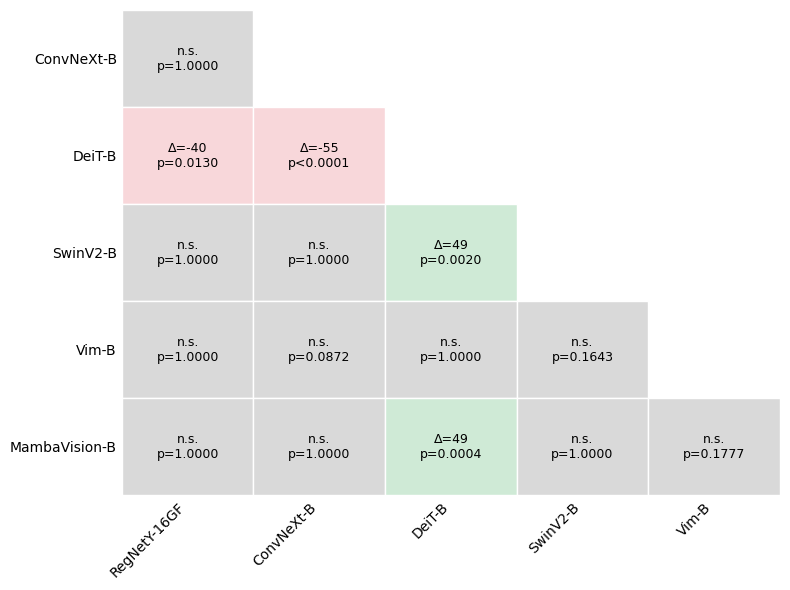

In [29]:
model_names = list(predictions.keys())
plot_significance_grid(results_df, model_names, alpha=0.05)